# Model 6 - K-Means (+ PCA) : Training, Evaluation & Deployment
**IT2011 AI/ML · PurchaseSense (Online Shoppers Purchasing Intention)**

| Requirement | Section |
|---|---|
| Model suitability to the dataset and problem | **2** |
| Implementation details (libraries, functions, hyperparameters) | **3** (+ the tables printed in 4–6) |
| Parameter tuning methods | **4** (stage 1: preprocessing + k) and **5** (stage 2: GridSearchCV on K-Means settings) |
| Number and variety of models trained | **4–5** (counts printed at the end of each) |
| Evaluation metrics, why appropriate, validation method | **3**, **4**, **7** |
| Comparison across varieties + conclusion | **4** and **6** |
| Limitations / improvements | **9** |
| Demonstration of code + output, deployment | **8** |

In [2]:
import os, sys, json, time, shutil, warnings
warnings.filterwarnings('ignore')
for f in ['data/raw', 'results/eda_visualizations', 'results/outputs', 'models', 'deployment']:
    os.makedirs(f, exist_ok=True)

DATA_PATH = 'data/raw/online_shoppers_intention.csv'
if not os.path.exists(DATA_PATH):
    try:                                   # Colab: upload the CSV once
        from google.colab import files
        print("Please upload 'online_shoppers_intention.csv'")
        up = files.upload()
        for fn in up: os.rename(fn, DATA_PATH)
    except ImportError:
        raise FileNotFoundError(f"Put online_shoppers_intention.csv in {DATA_PATH}")
print('Dataset found:', DATA_PATH)

Dataset found: data/raw/online_shoppers_intention.csv


In [3]:
%%writefile kmeans_prep.py
"""Helper code for the K-Means model (Model 6).
Kept in its own file so the saved joblib pipeline can be loaded later by predict.py / app.py."""
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

# one-hot with drop_first=True (same result as the group pipeline's pd.get_dummies): 'Aug' and 'New_Visitor' are the dropped baselines
MONTHS_KEPT = ['Dec', 'Feb', 'Jul', 'June', 'Mar', 'May', 'Nov', 'Oct', 'Sep']
VISITORS_KEPT = ['Other', 'Returning_Visitor']


def add_features(raw: pd.DataFrame) -> pd.DataFrame:
    """Row-by-row feature building (no statistics are learned here, so it is safe to run BEFORE the split).
    Mirrors the group pipeline: log1p columns, engineered totals, 0/1 encoding, one-hot encoding."""
    df = raw.copy()
    for c in ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'PageValues']:
        df[c + '_log'] = np.log1p(df[c])
    df['Total_Pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']
    df['Total_Duration'] = df['Administrative_Duration'] + df['Informational_Duration'] + df['ProductRelated_Duration']
    df['Avg_Duration_Per_Page'] = df['Total_Duration'] / (df['Total_Pages'] + 1.0)
    df['Weekend'] = df['Weekend'].astype(int)
    for m in MONTHS_KEPT:
        df['Month_' + m] = (df['Month'] == m).astype(int)
    for v in VISITORS_KEPT:
        df['VisitorType_' + v] = (df['VisitorType'] == v).astype(int)
    if 'Revenue' in df.columns:               # not present for a brand-new live session
        df['Revenue'] = df['Revenue'].astype(int)
    return df.drop(columns=['Month', 'VisitorType'])


class ColumnSelector(BaseEstimator, TransformerMixin):
    """Keeps only the chosen columns (so each variety can use a different feature set)."""
    def __init__(self, cols=None):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[list(self.cols)]


class Winsorizer(BaseEstimator, TransformerMixin):
    """IQR outlier capping. Bounds are learned on the training part only, then applied to any data."""
    def __init__(self, factor=1.5):
        self.factor = factor
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        q1, q3 = X.quantile(0.25), X.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = (q1 - self.factor * iqr).values
        self.upper_ = (q3 + self.factor * iqr).values
        # columns where IQR == 0 (e.g. mostly zeros) would collapse to a constant -> leave them uncapped
        self.skip_ = (iqr.values == 0)
        return self
    def transform(self, X):
        A = np.asarray(X, dtype=float).copy()
        lo = np.where(self.skip_, -np.inf, self.lower_)
        hi = np.where(self.skip_, np.inf, self.upper_)
        return np.clip(A, lo, hi)


class ClusterFeaturizer(BaseEstimator, TransformerMixin):
    """Used only for the 'does a cluster label help a supervised model?' experiment.
    Fits scaler + K-Means on the training part only and appends one-hot cluster columns."""
    def __init__(self, cols=None, k=3):
        self.cols = cols
        self.k = k
    def fit(self, X, y=None):
        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans
        self.sc_ = StandardScaler().fit(X[list(self.cols)])
        self.km_ = KMeans(self.k, n_init=10, random_state=42).fit(self.sc_.transform(X[list(self.cols)]))
        return self
    def transform(self, X):
        lab = self.km_.predict(self.sc_.transform(X[list(self.cols)]))
        return np.hstack([X.values, np.eye(self.k)[lab]])

Writing kmeans_prep.py


In [4]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, roc_auc_score, average_precision_score,
                             f1_score, precision_score, recall_score)
from kmeans_prep import add_features, ColumnSelector, Winsorizer, ClusterFeaturizer
sns.set_style('whitegrid'); pd.set_option('display.max_columns', None); pd.set_option('display.width', 220)
RS = 42

raw = pd.read_csv(DATA_PATH)
df  = add_features(raw)                    # row-by-row only -> no leakage, safe before the split
y   = df['Revenue']                        # ONLY used to describe clusters, never to fit them
X   = df.drop(columns='Revenue')

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
print('Train', Xtr.shape, '| Test', Xte.shape)
print('Purchase share  train: %.4f   test: %.4f' % (ytr.mean(), yte.mean()))
print('Duplicate rows in raw data:', raw.duplicated().sum(), '(kept, same as group)')
print('\nFirst 5 test-row indices (all members should see exactly these):', list(Xte.index[:5]))

Train (9864, 33) | Test (2466, 33)
Purchase share  train: 0.1547   test: 0.1549
Duplicate rows in raw data: 125 (kept, same as group)

First 5 test-row indices (all members should see exactly these): [4722, 6835, 5524, 663, 136]


## 2. Model suitability — is K-Means a sensible choice here?

**Problem:** the group predicts `Revenue` (purchase yes/no). K-Means is *unsupervised*: it never sees `Revenue`. Its job in our project is different and complementary: **find natural shopper segments from browsing behaviour**, then check whether those segments differ in purchase rate.

**Why it fits the data**
- The behaviour columns (pages viewed, time spent, bounce/exit rates, special-day closeness) are numeric and measured on every session.
- We have no segment labels — clustering is the natural tool.
- Segments are useful to a shop: different groups need different marketing.

**What K-Means assumes (and the risks here)**
- It uses straight-line distance → features **must be scaled**
- It likes roughly round, similar-sized groups, and it is **pulled by outliers and skew**.
- Binary / one-hot columns and ID-like codes (`Browser`, `Region`, `TrafficType`) are not meaningful for distance → I test these as varieties.

Below: two quick checks — how skewed the features are, and the **Hopkins statistic** (≈0.5 = no cluster structure, close to 1 = strong cluster tendency).

Hopkins statistic (behaviour features, mean of 5 samples): 0.972

Skewness (0 = symmetric):
                         skew_raw  skew_after_log1p
Administrative_Duration      5.68              0.25
Informational_Duration       7.70              1.92
ProductRelated_Duration      8.01             -1.42
PageValues                   6.19              1.80


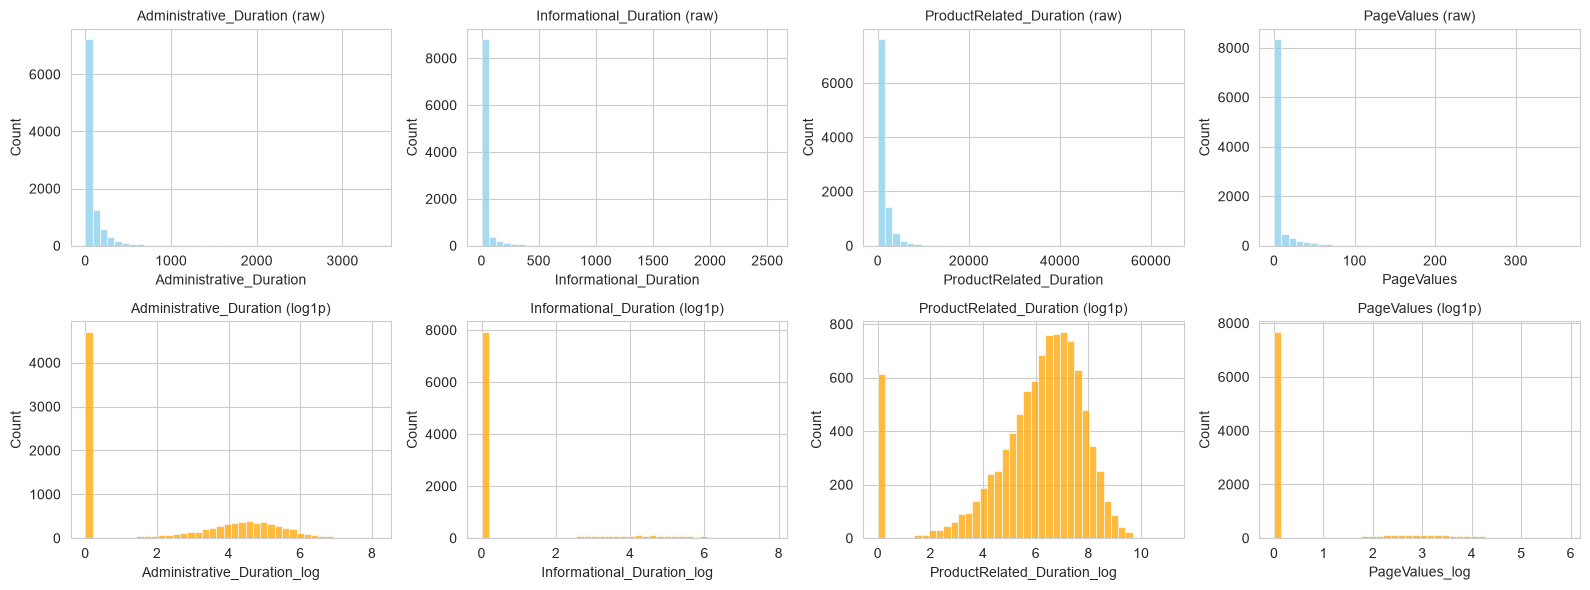

In [5]:
from sklearn.neighbors import NearestNeighbors

def hopkins(A, m=500, seed=42):
    rng = np.random.RandomState(seed); n, d = A.shape; m = min(m, n - 1)
    nn = NearestNeighbors(n_neighbors=2).fit(A)
    w = nn.kneighbors(A[rng.choice(n, m, replace=False)], 2)[0][:, 1]       # real point -> nearest other real point
    u = nn.kneighbors(rng.uniform(A.min(0), A.max(0), (m, d)), 1)[0][:, 0]  # random point -> nearest real point
    return u.sum() / (u.sum() + w.sum())

BEH_LOG = ['Administrative', 'Informational', 'ProductRelated',
           'Administrative_Duration_log', 'Informational_Duration_log', 'ProductRelated_Duration_log',
           'BounceRates', 'ExitRates', 'PageValues_log', 'SpecialDay',
           'Total_Pages', 'Total_Duration', 'Avg_Duration_Per_Page']
A = StandardScaler().fit_transform(Xtr[BEH_LOG])
print('Hopkins statistic (behaviour features, mean of 5 samples): %.3f' % np.mean([hopkins(A, seed=s) for s in range(5)]))

skew_cols = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'PageValues']
sk = pd.DataFrame({'skew_raw': [Xtr[c].skew() for c in skew_cols],
                   'skew_after_log1p': [Xtr[c + '_log'].skew() for c in skew_cols]}, index=skew_cols).round(2)
print('\nSkewness (0 = symmetric):'); print(sk)

fig, ax = plt.subplots(2, 4, figsize=(16, 6))
for i, c in enumerate(skew_cols):
    sns.histplot(Xtr[c], bins=40, ax=ax[0, i], color='skyblue');  ax[0, i].set_title(c + ' (raw)', fontsize=10)
    sns.histplot(Xtr[c + '_log'], bins=40, ax=ax[1, i], color='orange'); ax[1, i].set_title(c + ' (log1p)', fontsize=10)
plt.tight_layout(); plt.savefig('results/eda_visualizations/kmeans_step1_skew.png', dpi=120); plt.show()

**intepretation:** Hopkins is far above 0.5, so the data has real cluster structure. The raw durations/PageValues are extremely right-skewed (a few huge values) and `log1p` pulls them in. That is why *"log vs raw"* and *"capping"* are two of my varieties.

**note:** "K-Means is suitable because I want customer segments, the key features are numeric, and Hopkins shows the data is clusterable. Its weaknesses — scale sensitivity, outliers, spherical clusters — are exactly what the varieties test."

## 3. Implementation design & evaluation method

**Libraries / functions:** `sklearn.cluster.KMeans`, `sklearn.decomposition.PCA`, `sklearn.preprocessing` (Standard / MinMax / Robust scalers), `sklearn.pipeline.Pipeline`, `GridSearchCV`, `StratifiedKFold`, `sklearn.metrics`, plus two small custom steps in `kmeans_prep.py` (`ColumnSelector`, `Winsorizer`).

**How K-Means works:** pick K centres → assign every session to its nearest centre → move each centre to the mean of its group → repeat until nothing changes.

**Metrics used and why:**

| Metric | Meaning | Better is | Why used |
|---|---|---|---|
| Inertia | Total squared distance to own centre (slide 236) | lower | Elbow plot for choosing K (slide 238). Always falls as K grows, so it cannot pick K alone |
| **Silhouette** | How much closer a session is to its own cluster than to the next one (−1…1) | higher | **Main tuning score** (to keep one score for all varieties) |
| Davies-Bouldin | Average similarity between each cluster and its closest rival | lower | Second opinion; scikit-learn has no Dunn index, and DB is a similar "separation vs. spread" idea |
| Calinski-Harabasz | Between-cluster spread / within-cluster spread | higher | Third opinion |
| Purchase rate per cluster | Share of buyers in each cluster | – | **External check** using `Revenue` *after* clustering |

**Validation method (replaces train/test accuracy):** K-Means has no labels to score against, so I use **stratified 5-fold cross-validation** (`StratifiedKFold(5, shuffle=True, random_state=42)`. In every fold the *whole pipeline* (cap → scale → PCA → K-Means) is **fitted on 4 folds and the silhouette is measured on the held-out fold**. Folds are stratified on `Revenue` only so each fold has the same buyer share; the labels are never given to K-Means.

**Fair comparison across varieties:** silhouettes measured in different feature spaces (e.g. 33 columns vs 12) are not directly comparable. So I record two numbers: `sil` (in the variety's own space) and `sil_common` (the same cluster labels measured in one fixed reference space = the 13 scaled behaviour features). Compare **varieties** with `sil_common`; use `sil` to pick **K within** a variety.

In [6]:
# ---------------- feature sets ----------------
ALL     = list(X.columns)                                      # everything the group pipeline had (33 columns)
BEH_RAW = ['Administrative', 'Informational', 'ProductRelated',
           'Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration',
           'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
           'Total_Pages', 'Total_Duration', 'Avg_Duration_Per_Page']
BEH_NOPV = [c for c in BEH_LOG if c != 'PageValues_log']     # behaviour without PageValues
COMPACT  = ['ProductRelated', 'ProductRelated_Duration_log', 'Administrative', 'Administrative_Duration_log',
            'ExitRates', 'PageValues_log', 'SpecialDay']        # 7 core features, no engineered sums
BEH_CTX  = BEH_LOG + ['Weekend', 'VisitorType_Other', 'VisitorType_Returning_Visitor']

SCALERS = {'std': StandardScaler, 'minmax': MinMaxScaler, 'robust': RobustScaler}

def make_pipe(cols, scaler='std', cap=False, pca=None):
    """select columns -> (cap outliers) -> scale -> (PCA) -> K-Means. All learned steps are fitted on training data only."""
    steps = [('sel', ColumnSelector(cols))]
    if cap: steps.append(('cap', Winsorizer()))
    steps.append(('sc', SCALERS[scaler]()))
    if pca:  steps.append(('pca', PCA(n_components=pca, random_state=RS)))
    steps.append(('km', KMeans(n_init=10, random_state=RS)))
    return Pipeline(steps)

# ---------------- reference space for fair comparison ----------------
ref = Pipeline([('sel', ColumnSelector(BEH_LOG)), ('sc', StandardScaler())]).fit(Xtr)

# ---------------- custom scorers: GridSearchCV calls scorer(estimator, X_heldout_fold, y) ----------------
def _labels(est, Xv):
    Z = est[:-1].transform(Xv); return Z, est[-1].predict(Z)
def sil_own(est, Xv, y=None):
    Z, l = _labels(est, Xv); return silhouette_score(Z, l) if len(set(l)) > 1 else -1
def sil_common(est, Xv, y=None):
    Z, l = _labels(est, Xv); return silhouette_score(ref.transform(Xv), l) if len(set(l)) > 1 else -1
def dbi_neg(est, Xv, y=None):          # negative so that "bigger = better" for GridSearchCV; flipped back when reported
    Z, l = _labels(est, Xv); return -davies_bouldin_score(Z, l) if len(set(l)) > 1 else -9
def ch_score(est, Xv, y=None):
    Z, l = _labels(est, Xv); return calinski_harabasz_score(Z, l) if len(set(l)) > 1 else 0
SCORERS = {'sil': sil_own, 'sil_common': sil_common, 'dbi': dbi_neg, 'ch': ch_score}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
print('Setup ready')

Setup ready


**Viva note (implementation details):** "Everything is one scikit-learn `Pipeline`, so the scaler, the outlier caps and PCA are re-learned inside each CV fold — no information from the held-out fold leaks in. I score each fold with silhouette, Davies-Bouldin and Calinski-Harabasz using custom scorers in `GridSearchCV`. The stratified folds use `Revenue` only to keep fold sizes balanced; K-Means itself never sees it."

## 4. Stage 1 — train and compare 13 varieties (preprocessing × K)

Each variety changes **preprocessing** (feature set, log vs raw, outlier capping, scaler type, PCA). 
For each one, `GridSearchCV` tries **K = 2 … 8** with 5-fold CV (this is the *hyperparameter tuning* of K; PCA is the dimensionality-reduction step).

| Code | What changes | Question it answers |
|---|---|---|
| V01 | all 33 features | Baseline: what if we cluster on everything? |
| V02 | V01 + PCA (90% variance) | Does PCA rescue the all-feature version? |
| V03 | behaviour features, **raw** (no log) | Does skew hurt? |
| V04 | behaviour features, **log**, StandardScaler | Main candidate |
| V05 | V04 + **outlier capping** | Does capping help K-Means? |
| V06 | V04 with **MinMaxScaler** | Scaler type |
| V07 | V04 with **RobustScaler** | Scaler type |
| V08 | V04 + **PCA 90%** | PCA on clean features |
| V09 | behaviour **without PageValues** | Do segments survive without the feature most linked to buying? |
| V10 | 7 compact features | Fewer, less redundant features |
| V11 | V04 + visitor type + weekend | Does context help? |
| V12 | V04 + capping + PCA 90% | Combination |
| V13 | V09 + PCA 90% | PCA on the V09 features |

In [7]:
VARIETIES = [
 ('V01 all features',            ALL,      'std',    False, None),
 ('V02 all features + PCA90',    ALL,      'std',    False, 0.90),
 ('V03 behaviour RAW (no log)',  BEH_RAW,  'std',    False, None),
 ('V04 behaviour LOG',           BEH_LOG,  'std',    False, None),
 ('V05 V04 + capping',           BEH_LOG,  'std',    True,  None),
 ('V06 V04 MinMax scaler',       BEH_LOG,  'minmax', False, None),
 ('V07 V04 Robust scaler',       BEH_LOG,  'robust', False, None),
 ('V08 V04 + PCA90',             BEH_LOG,  'std',    False, 0.90),
 ('V09 behaviour w/o PageValues',BEH_NOPV, 'std',    False, None),
 ('V10 compact 7 features',      COMPACT,  'std',    False, None),
 ('V11 V04 + visitor/weekend',   BEH_CTX,  'std',    False, None),
 ('V12 V04 + capping + PCA90',   BEH_LOG,  'std',    True,  0.90),
 ('V13 V09 + PCA90',             BEH_NOPV, 'std',    False, 0.90),
]
K_RANGE = list(range(2, 9))

t0 = time.time(); long_rows = []
for name, cols, scaler, cap, pca in VARIETIES:
    gs = GridSearchCV(make_pipe(cols, scaler, cap, pca), {'km__n_clusters': K_RANGE},
                      scoring=SCORERS, refit=False, cv=cv, n_jobs=-1)
    gs.fit(Xtr, ytr)                       # ytr is used ONLY by StratifiedKFold to balance the folds
    r = pd.DataFrame(gs.cv_results_)
    for _, row in r.iterrows():
        long_rows.append(dict(variety=name, k=int(row['param_km__n_clusters']),
                              cv_sil=row['mean_test_sil'], sd=row['std_test_sil'],
                              cv_sil_common=row['mean_test_sil_common'],
                              cv_dbi=-row['mean_test_dbi'], cv_ch=row['mean_test_ch']))
    print(f'{name:32s} done  ({time.time()-t0:5.0f}s)')
cv_long = pd.DataFrame(long_rows)
n_fits_stage1 = len(VARIETIES) * len(K_RANGE) * cv.get_n_splits()
print(f'\nStage 1: {len(VARIETIES)} varieties x {len(K_RANGE)} values of K = {len(VARIETIES)*len(K_RANGE)} configurations, '
      f'{n_fits_stage1} model fits (5-fold CV)')

V01 all features                 done  (   20s)
V02 all features + PCA90         done  (   33s)
V03 behaviour RAW (no log)       done  (   44s)
V04 behaviour LOG                done  (   54s)
V05 V04 + capping                done  (   65s)
V06 V04 MinMax scaler            done  (   74s)
V07 V04 Robust scaler            done  (   84s)
V08 V04 + PCA90                  done  (   94s)
V09 behaviour w/o PageValues     done  (  106s)
V10 compact 7 features           done  (  114s)
V11 V04 + visitor/weekend        done  (  124s)
V12 V04 + capping + PCA90        done  (  133s)
V13 V09 + PCA90                  done  (  141s)

Stage 1: 13 varieties x 7 values of K = 91 configurations, 455 model fits (5-fold CV)


In [8]:
# ---------- one row per variety: best K overall and best K with at least 3 segments ----------
def profile_rate(pipe, Xa, ya):
    lab = pipe[-1].labels_
    d = pd.DataFrame({'c': lab, 'y': ya.values}).groupby('c').y.agg(['size', 'mean'])
    return d['size'].min() / len(ya), d['mean'].min(), d['mean'].max()

rows = []
for name, cols, scaler, cap, pca in VARIETIES:
    v = cv_long[cv_long.variety == name]
    best_any = v.loc[v.cv_sil.idxmax()]
    v3 = v[v.k >= 3]; b = v3.loc[v3.cv_sil.idxmax()]
    k = int(b.k)
    p = make_pipe(cols, scaler, cap, pca).set_params(km__n_clusters=k).fit(Xtr)     # full training set
    ms, rmin, rmax = profile_rate(p, Xtr, ytr)
    rows.append(dict(variety=name, n_inputs=len(cols), best_k_any=int(best_any.k), best_k_3plus=k,
                     cv_sil=round(b.cv_sil, 3), sd=round(b.sd, 3), cv_sil_common=round(b.cv_sil_common, 3),
                     cv_dbi=round(b.cv_dbi, 3), cv_ch=round(b.cv_ch), min_cluster_share=round(ms, 3),
                     buy_rate_min=round(rmin, 3), buy_rate_max=round(rmax, 3)))
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
summary.to_csv('results/outputs/kmeans_stage1_summary.csv', index=False)

                     variety  n_inputs  best_k_any  best_k_3plus  cv_sil    sd  cv_sil_common  cv_dbi  cv_ch  min_cluster_share  buy_rate_min  buy_rate_max
            V01 all features        33           2             3   0.175 0.005          0.372   1.982    208              0.082         0.002         0.290
    V02 all features + PCA90        33           2             3   0.187 0.005          0.372   1.862    232              0.082         0.004         0.292
  V03 behaviour RAW (no log)        13           2             3   0.415 0.009          0.382   1.158    505              0.085         0.005         0.292
           V04 behaviour LOG        13           3             3   0.369 0.007          0.369   1.177    605              0.078         0.004         0.279
           V05 V04 + capping        13           2             3   0.240 0.006          0.210   1.443    674              0.205         0.018         0.272
       V06 V04 MinMax scaler        13           2             6

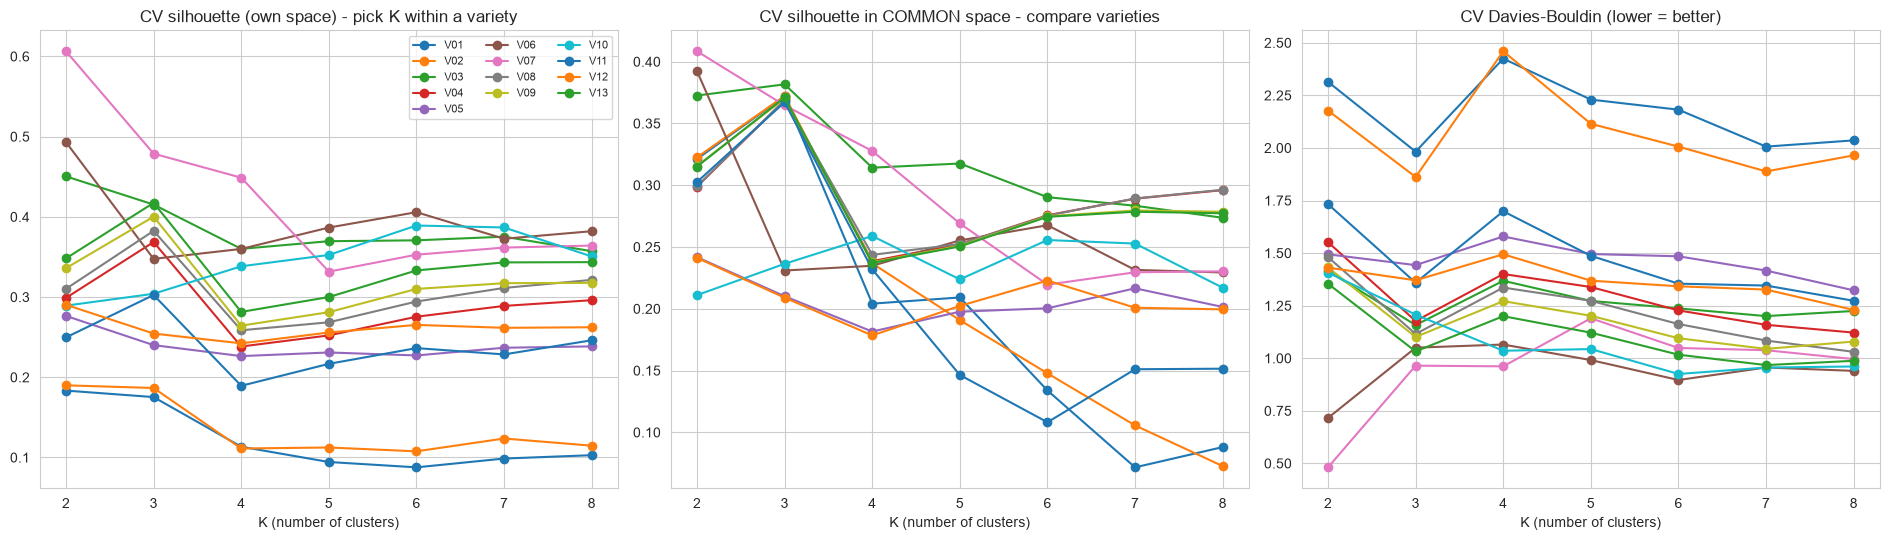

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(19, 5.5))
for name, *_ in VARIETIES:
    v = cv_long[cv_long.variety == name]
    ax[0].plot(v.k, v.cv_sil, marker='o', label=name[:3])
    ax[1].plot(v.k, v.cv_sil_common, marker='o', label=name[:3])
    ax[2].plot(v.k, v.cv_dbi, marker='o', label=name[:3])
ax[0].set_title('CV silhouette (own space) - pick K within a variety'); ax[1].set_title('CV silhouette in COMMON space - compare varieties')
ax[2].set_title('CV Davies-Bouldin (lower = better)')
for a in ax: a.set_xlabel('K (number of clusters)')
ax[0].legend(ncol=3, fontsize=8)
plt.tight_layout(); plt.savefig('results/eda_visualizations/kmeans_step2_variety_comparison.png', dpi=120); plt.show()

### Reading the comparison (what we found in our run — your numbers should be very close)

**Read the two silhouette columns differently.** `cv_sil` is measured in each variety's *own* feature space, so a 33-column variety and a 12-column variety are not on the same ruler. `cv_sil_common` measures the same cluster labels in one fixed space, so it is the fair column for comparing varieties. (Davies-Bouldin and Calinski-Harabasz are also own-space numbers.)

- **At K = 3 almost every variety finds the same three segments.** In the common space, V01–V04, V08, V09, V11 and V13 are all within about 0.015 of each other (≈ 0.37–0.38), and their purchase rates run from ≈ 0.3% to ≈ 27–29%. Preprocessing matters much less than I first expected.
- **The own-space silhouette of the all-feature versions (V01, V02 ≈ 0.18) looks bad but is misleading.** With 33 noisy dimensions (months, visitor type, browser/region codes, duplicated raw + log columns) every distance looks similar, so the number is low even though the clusters are about as good in the common space (0.372). Own-space numbers can only be compared *within* a variety.
- **Outlier capping clearly hurts (V05, V12: common silhouette ≈ 0.21–0.22).** Many sessions have zeros in several columns, so the IQR bounds are tight; the "quick exit" group is no longer a separate cluster (smallest cluster jumps to ≈ 20% of sessions). For K-Means here, log + scaling beats capping.
- **Raw vs log (V03 vs V04):** about the same at K = 3 (0.382 vs 0.369), so I cannot claim a measured gain from the log transform. I keep it because the raw durations are extremely skewed and distance-based methods are pulled by a few huge values.
- **Scalers:** the Robust scaler has the highest own-space silhouette (0.479) but only 0.365 in the common space — it changes the geometry, not the segments. MinMax (V06) and the compact 7-feature set (V10) preferred K = 6 and score poorly in the common space.
- **PCA (V02, V08, V12, V13) is neutral:** common-space scores equal the non-PCA twins (V08 0.369 vs V04 0.369; V13 0.371 vs V09 0.370). The data are already low-dimensional after feature selection, so PCA's main value here is **visualisation** (section 6).
- **Adding visitor type / weekend (V11)** lowers the own-space score (0.303 vs 0.369) and changes nothing in the common space.
- **Removing PageValues (V09)** keeps the same segments (0.370). That matters: PageValues is calculated from pages that led to a purchase, so it is close to the target. Segments that appear *without* it are more convincing.
- **K = 2 often wins on silhouette, but it only splits off the "bouncers"** from everybody else. That is why the table also shows the best K with at least 3 segments.

**Which variety is final?** Because several varieties are statistically tied, I use a transparent rule: shortlist every variety within 0.015 of the best common-space silhouette (≥ 3 clusters, every cluster ≥ 5% of sessions), then prefer **(1) no PageValues, (2) no PCA, (3) fewer inputs.**

In [10]:
cand = summary[(summary.min_cluster_share >= 0.05)].copy()
best_common = cand.cv_sil_common.max()
shortlist = cand[cand.cv_sil_common >= best_common - 0.015].copy()
spec = {v[0]: v for v in VARIETIES}
shortlist['uses_PageValues'] = [any('PageValues' in c for c in spec[n][1]) for n in shortlist.variety]
shortlist['uses_PCA']        = [spec[n][4] is not None for n in shortlist.variety]
shortlist = shortlist.sort_values(['uses_PageValues', 'uses_PCA', 'n_inputs', 'cv_sil_common'], ascending=[True, True, True, False])
print('Shortlist (common-space silhouette within 0.015 of the best, clusters >= 5% of sessions), in order of preference:')
print(shortlist[['variety', 'best_k_3plus', 'n_inputs', 'cv_sil', 'cv_sil_common', 'uses_PageValues', 'uses_PCA',
                 'buy_rate_min', 'buy_rate_max']].to_string(index=False))

FINAL_NAME = shortlist.iloc[0].variety
FINAL = spec[FINAL_NAME]
print('\nFinal variety (rule: no PageValues -> no PCA -> fewest inputs):', FINAL_NAME)

Shortlist (common-space silhouette within 0.015 of the best, clusters >= 5% of sessions), in order of preference:
                     variety  best_k_3plus  n_inputs  cv_sil  cv_sil_common  uses_PageValues  uses_PCA  buy_rate_min  buy_rate_max
V09 behaviour w/o PageValues             3        12   0.400          0.370            False     False         0.003         0.265
             V13 V09 + PCA90             3        12   0.417          0.371            False      True         0.004         0.266
  V03 behaviour RAW (no log)             3        13   0.415          0.382             True     False         0.005         0.292
           V04 behaviour LOG             3        13   0.369          0.369             True     False         0.004         0.279
   V11 V04 + visitor/weekend             3        16   0.303          0.367             True     False         0.004         0.279
            V01 all features             3        33   0.175          0.372             True     Fal

**Viva note (comparison + conclusion):** "I trained 13 varieties of K-Means: all features, behaviour only, raw vs log, capping, three scalers, PCA, and with or without PageValues. Validation was 5-fold stratified CV with the pipeline refitted in every fold. Because silhouettes from different feature spaces are not comparable, I also measured every variety in one common space. The result: at K = 3 most varieties find the same three segments, capping hurts, PCA is neutral, and the segments survive without PageValues — so I chose the simplest variety, V09."

## 5. Stage 2 — choosing K properly, then tuning the K-Means settings

**Choosing K (lecture slide 238, "Selecting K").** The elbow plot uses inertia; inertia always falls as K grows, so I read it together with silhouette and Davies-Bouldin.

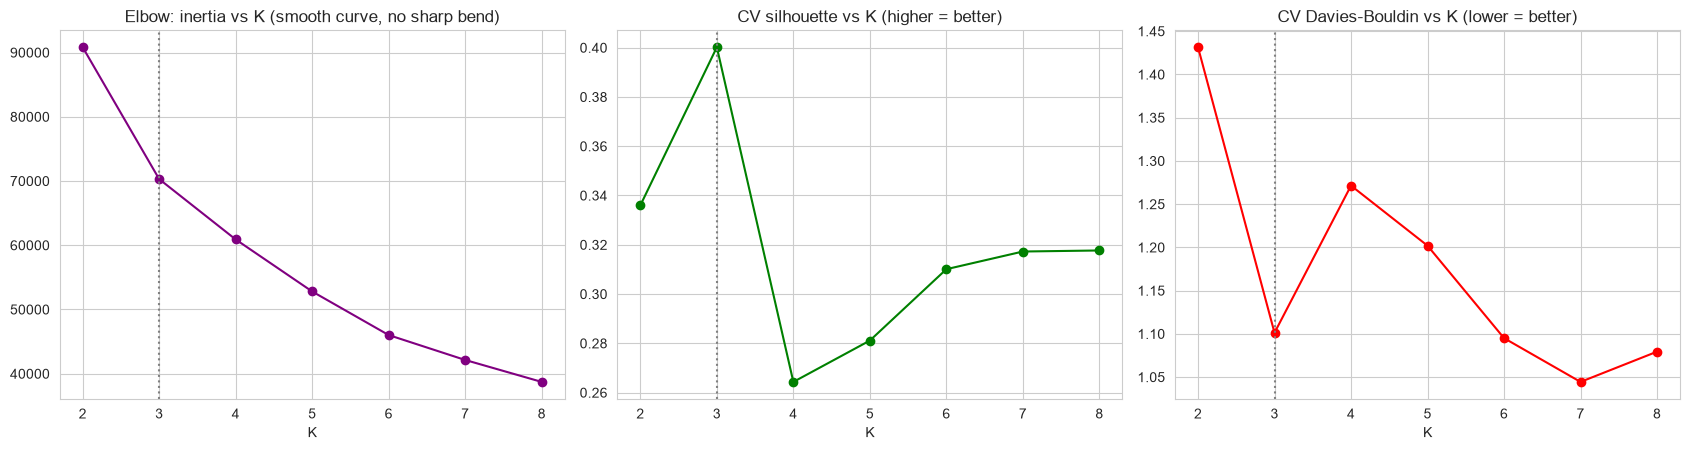

                    2            3             4            5             6             7             8
inertia  90827.541319  70292.53287  60897.906555  52796.62263  46012.844105  42134.904146  38719.833669
cv_sil       0.336000      0.40000      0.264000      0.28100      0.310000      0.317000      0.318000
cv_dbi       1.431000      1.10100      1.271000      1.20200      1.095000      1.044000      1.079000


In [11]:
v = cv_long[cv_long.variety == FINAL_NAME].set_index('k')
inertia = {}
for k in K_RANGE:
    p = make_pipe(*FINAL[1:]).set_params(km__n_clusters=k).fit(Xtr)
    inertia[k] = p[-1].inertia_

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
ax[0].plot(K_RANGE, list(inertia.values()), 'o-', color='purple'); ax[0].set_title('Elbow: inertia vs K (smooth curve, no sharp bend)')
ax[1].plot(K_RANGE, v.cv_sil.values, 'o-', color='green'); ax[1].set_title('CV silhouette vs K (higher = better)')
ax[2].plot(K_RANGE, v.cv_dbi.values, 'o-', color='red'); ax[2].set_title('CV Davies-Bouldin vs K (lower = better)')
for a in ax: a.set_xlabel('K'); a.axvline(3, ls=':', color='grey')
plt.tight_layout(); plt.savefig('results/eda_visualizations/kmeans_step3_choose_k.png', dpi=120); plt.show()
print(pd.DataFrame({'inertia': inertia, 'cv_sil': v.cv_sil.round(3), 'cv_dbi': v.cv_dbi.round(3)}).T.to_string())

**Reading it:** the elbow curve bends gently, so inertia alone does not give a clear K. Silhouette peaks sharply at **K = 3** (0.40, then it drops to ≈ 0.26–0.32 for K ≥ 4). Davies-Bouldin is good at K = 3 (1.10) but is slightly lower at K = 7 (1.04), so it does not contradict K = 3 but it does not single it out either. I use **silhouette as the main score** (as decided in section 3), so **K = 3** is the best-supported choice. Say this honestly in the viva: "the elbow is not sharp, silhouette clearly peaks at 3, Davies-Bouldin agrees that 3 is reasonable."

**Tuning the remaining K-Means settings with `GridSearchCV`** (lecture slides 44–47: hyperparameters are settings you choose before training; grid search tries every combination).

| Hyperparameter | Values tried | What it does |
|---|---|---|
| `n_clusters` | 3, 4, 5 | number of segments |
| `init` | `k-means++`, `random` | how the first centres are chosen |
| `n_init` | 1, 10, 20 | how many times K-Means restarts from new centres (best run is kept) |
| `algorithm` | `lloyd`, `elkan` | computation method (same result, different speed) |
| `max_iter` | 100, 300 | max rounds per run |

In [12]:
grid = {'km__n_clusters': [3, 4, 5], 'km__init': ['k-means++', 'random'], 'km__n_init': [1, 10, 20],
        'km__algorithm': ['lloyd', 'elkan'], 'km__max_iter': [100, 300]}
t0 = time.time()
gs2 = GridSearchCV(make_pipe(*FINAL[1:]), grid, scoring=SCORERS, refit=False, cv=cv, n_jobs=-1).fit(Xtr, ytr)
r2 = pd.DataFrame(gs2.cv_results_)
r2['cv_dbi'] = -r2['mean_test_dbi']
n_cfg2 = len(r2); n_fits2 = n_cfg2 * cv.get_n_splits()
print(f'Stage 2: {n_cfg2} configurations, {n_fits2} model fits ({time.time()-t0:.0f}s)\n')

cols_show = ['param_km__n_clusters', 'param_km__init', 'param_km__n_init', 'param_km__algorithm', 'param_km__max_iter',
             'mean_test_sil', 'std_test_sil', 'cv_dbi']
print('Top 6 configurations by CV silhouette:')
print(r2.sort_values('mean_test_sil', ascending=False)[cols_show].head(6).round(4).to_string(index=False))

print('\nAverage CV silhouette by each hyperparameter (all other settings averaged out):')
for p in ['param_km__n_clusters', 'param_km__init', 'param_km__n_init', 'param_km__algorithm', 'param_km__max_iter']:
    print(f'  {p.replace("param_km__", ""):12s}', r2.groupby(p).mean_test_sil.mean().round(4).to_dict())
r3 = r2[r2.param_km__n_clusters == 3]
print(f'\nAt K=3 the CV silhouette only ranges from {r3.mean_test_sil.min():.4f} to {r3.mean_test_sil.max():.4f} across all {len(r3)} settings')

Stage 2: 72 configurations, 360 model fits (102s)

Top 6 configurations by CV silhouette:
 param_km__n_clusters param_km__init  param_km__n_init param_km__algorithm  param_km__max_iter  mean_test_sil  std_test_sil  cv_dbi
                    3         random                 1               lloyd                 100         0.4010        0.0077  1.0998
                    3         random                 1               elkan                 300         0.4010        0.0077  1.0998
                    3         random                 1               elkan                 100         0.4010        0.0077  1.0998
                    3         random                 1               lloyd                 300         0.4010        0.0077  1.0998
                    3         random                10               elkan                 300         0.4006        0.0081  1.1006
                    3         random                10               elkan                 100         0.4006        0

**Reading it:** only **K** matters. At K = 3, every combination of `init`, `n_init`, `algorithm` and `max_iter` lands within about 0.001 of each other — that is noise, not a real difference. `algorithm` and `max_iter` change nothing at all. So I keep the standard, safest settings: **`init='k-means++'`, `n_init=10`, `algorithm='lloyd'`, `max_iter=300`, K = 3**. The next check explains why `n_init` should not be 1.

*Counts for the viva:* stage 1 trained **13 varieties × 7 values of K**; stage 2 trained **72 more configurations** (each evaluated with 5-fold CV), plus the final model.

In [13]:
print(f'Stage 1: {len(VARIETIES)*len(K_RANGE)} configurations / {n_fits_stage1} fits')
print(f'Stage 2: {n_cfg2} configurations / {n_fits2} fits')
print(f'Total  : {len(VARIETIES)*len(K_RANGE) + n_cfg2} configurations / {n_fits_stage1 + n_fits2} CV fits (+ final model on the full training set)')

K_FINAL = 3
FINAL_PARAMS = dict(km__n_clusters=K_FINAL, km__init='k-means++', km__n_init=10, km__algorithm='lloyd', km__max_iter=300)
final_pipe = make_pipe(*FINAL[1:]).set_params(**FINAL_PARAMS).fit(Xtr)
Ztr = final_pipe[:-1].transform(Xtr)
lab_tr = final_pipe.predict(Xtr)
print('\nFinal model fitted on the full training set. Inertia = %.1f, iterations = %d' % (final_pipe[-1].inertia_, final_pipe[-1].n_iter_))

Stage 1: 91 configurations / 455 fits
Stage 2: 72 configurations / 360 fits
Total  : 163 configurations / 815 CV fits (+ final model on the full training set)

Final model fitted on the full training set. Inertia = 70292.5, iterations = 6


## 6. The final model — who are the three segments?

Now I use `Revenue` for the first time, **only to describe** the clusters. Segments are named by how many pages the sessions viewed.

Segment profile on the TRAINING set (means in original units):
c                                        1                0                 2
segment                        Quick exits  Casual browsers  Engaged shoppers
Administrative                        0.03             1.58              6.34
Informational                         0.02             0.13              2.24
ProductRelated                        2.33            21.35             85.39
Administrative_Duration               0.13            53.48            229.88
Informational_Duration                0.07             4.05            174.69
ProductRelated_Duration              21.21           787.23           3324.14
BounceRates                           0.18             0.01              0.01
ExitRates                             0.19             0.03              0.02
PageValues                             0.0             5.77              9.19
SpecialDay                             0.1             0.07              0.04
T

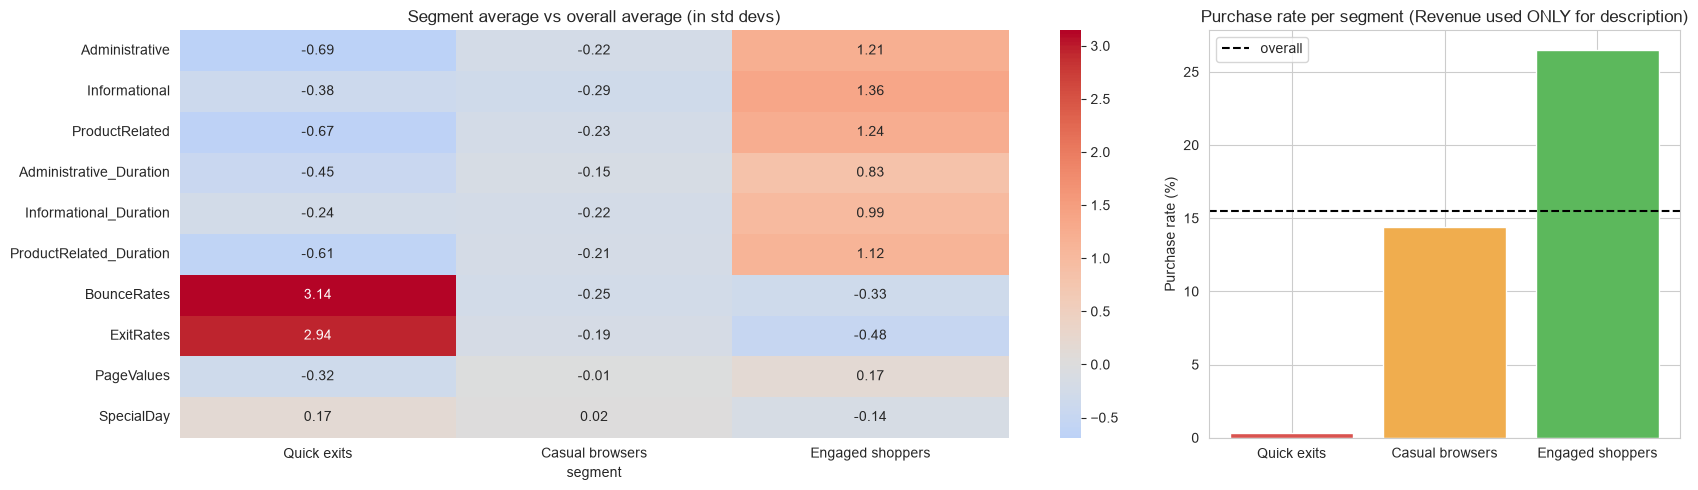

In [14]:
PROFILE_COLS = ['Administrative', 'Informational', 'ProductRelated', 'Administrative_Duration',
                'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

order = Xtr.assign(c=lab_tr).groupby('c').Total_Pages.mean().sort_values().index.tolist()      # low -> high engagement
NAMES = ['Quick exits', 'Casual browsers', 'Engaged shoppers']
seg_name = {c: NAMES[i] for i, c in enumerate(order)}

prof = Xtr[PROFILE_COLS + ['Total_Pages', 'Weekend', 'VisitorType_Returning_Visitor']].assign(c=lab_tr).groupby('c').mean()
prof['sessions'] = pd.Series(lab_tr).value_counts().sort_index()
prof['share_%'] = (prof['sessions'] / len(Xtr) * 100).round(1)
prof['purchase_rate_%'] = (pd.Series(ytr.values).groupby(lab_tr).mean() * 100).round(1)
prof.insert(0, 'segment', [seg_name[c] for c in prof.index])
prof = prof.loc[order]
print('Segment profile on the TRAINING set (means in original units):')
print(prof.round(2).T.to_string())
print('\nOverall purchase rate: %.1f%%' % (ytr.mean() * 100))

# heatmap of how far each segment is from the average (in standard deviations) + purchase-rate bars
z = (prof[PROFILE_COLS] - Xtr[PROFILE_COLS].mean()) / Xtr[PROFILE_COLS].std()
z.index = prof['segment']
fig, ax = plt.subplots(1, 2, figsize=(17, 5), gridspec_kw={'width_ratios': [2.2, 1]})
sns.heatmap(z.T, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax[0]); ax[0].set_title('Segment average vs overall average (in std devs)')
ax[1].bar(prof['segment'], prof['purchase_rate_%'], color=['#d9534f', '#f0ad4e', '#5cb85c'])
ax[1].axhline(ytr.mean() * 100, ls='--', color='k', label='overall'); ax[1].set_ylabel('Purchase rate (%)'); ax[1].legend()
ax[1].set_title('Purchase rate per segment (Revenue used ONLY for description)')
plt.tight_layout(); plt.savefig('results/eda_visualizations/kmeans_step4_segments.png', dpi=120); plt.show()

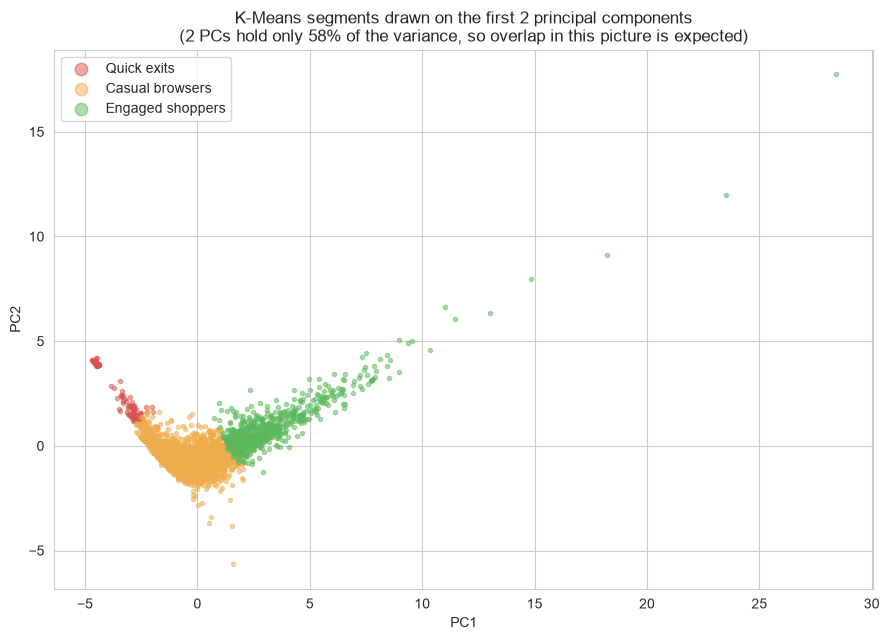

Final feature space has 12 columns. Components needed for 90% variance: 6, for 95%: 7


In [15]:
# PCA to 2 components: only for DRAWING the clusters (the clustering itself ran in the full space)
p2 = PCA(n_components=2, random_state=RS).fit(Ztr)
P = p2.transform(Ztr)
idx = np.random.RandomState(RS).choice(len(P), 3500, replace=False)
colors = {seg_name[c]: col for c, col in zip(order, ['#d9534f', '#f0ad4e', '#5cb85c'])}
plt.figure(figsize=(9, 6.5))
for c in order:
    m = idx[lab_tr[idx] == c]
    plt.scatter(P[m, 0], P[m, 1], s=9, alpha=.5, label=seg_name[c], color=colors[seg_name[c]])
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.legend(markerscale=3)
plt.title('K-Means segments drawn on the first 2 principal components\n(2 PCs hold only %.0f%% of the variance, so overlap in this picture is expected)' % (p2.explained_variance_ratio_.sum() * 100))
plt.tight_layout(); plt.savefig('results/eda_visualizations/kmeans_step5_pca_scatter.png', dpi=120); plt.show()

pfull = PCA(random_state=RS).fit(Ztr); cum = np.cumsum(pfull.explained_variance_ratio_)
print('Final feature space has %d columns. Components needed for 90%% variance: %d, for 95%%: %d' %
      (Ztr.shape[1], np.argmax(cum >= .9) + 1, np.argmax(cum >= .95) + 1))

**Reading it:**
- **Quick exits** — only a couple of pages, very high exit rate, zero PageValues, almost nobody buys (≈ 0.3%).
- **Casual browsers** — the big middle group (≈ 74%), purchase rate near the overall average (≈ 14%).
- **Engaged shoppers** — many product pages and long visits, low exit rate, high PageValues; the purchase rate is roughly **double** the average (≈ 27%).

K-Means never saw `Revenue` and never saw PageValues (in V09), yet the segments line up with buying behaviour. That is the headline result. Also note the 2-D picture: the clusters overlap there because 2 PCs keep only a fraction of the information — the clustering is done in the full space.

**Viva note (PCA's role):** "PCA appears in two ways: as a preprocessing variety (V02, V08, V12, V13 — it did not improve the clusters) and as a 2-D visualisation of the final clusters."

## 7. Validation — does it hold on unseen data, and is it stable?

The test set is touched **only now, for the final model** (guide: "score the test set only for your final variety"). Three checks:
1. **Held-out check:** assign test sessions to the *training* clusters — do shares and purchase rates look the same?
2. **Stability:** does the clustering change if the random start or the data sample changes?
3. **Approximate prediction power** (flagged as approximate — K-Means is not built to predict purchases).

In [16]:
lab_te = final_pipe.predict(Xte)
rate_tr = pd.Series(ytr.values).groupby(lab_tr).mean()

cmp = pd.DataFrame({
    'segment': [seg_name[c] for c in order],
    'train_share_%': [(lab_tr == c).mean() * 100 for c in order],
    'test_share_%':  [(lab_te == c).mean() * 100 for c in order],
    'train_purchase_%': [rate_tr[c] * 100 for c in order],
    'test_purchase_%':  [yte.values[lab_te == c].mean() * 100 for c in order]}).round(1)
print('1) Held-out check (test rows assigned to the clusters learned on training data):'); print(cmp.to_string(index=False))

Zte = final_pipe[:-1].transform(Xte)
test_metrics = dict(test_silhouette=silhouette_score(Zte, lab_te), test_davies_bouldin=davies_bouldin_score(Zte, lab_te),
                    test_calinski_harabasz=calinski_harabasz_score(Zte, lab_te))
print('\nTest-set cluster quality:', {k: round(v, 3) for k, v in test_metrics.items()})

1) Held-out check (test rows assigned to the clusters learned on training data):
         segment  train_share_%  test_share_%  train_purchase_%  test_purchase_%
     Quick exits            7.7           7.2               0.3              0.6
 Casual browsers           74.2          74.7              14.4             14.4
Engaged shoppers           18.1          18.0              26.5             25.8

Test-set cluster quality: {'test_silhouette': 0.409, 'test_davies_bouldin': 1.098, 'test_calinski_harabasz': 836.998}


In [17]:
# 2) Stability
ref_labels = lab_tr
# (a) random starts: single random initialisation, 20 different seeds
ari_seed = [adjusted_rand_score(ref_labels, KMeans(K_FINAL, n_init=1, init='random', random_state=s).fit(Ztr).labels_) for s in range(20)]
# (b) data sampling: refit the WHOLE pipeline on random 80% subsamples, label all training rows, compare
rng = np.random.RandomState(RS); ari_sub = []
for _ in range(20):
    idx = rng.choice(len(Xtr), int(.8 * len(Xtr)), replace=False)
    pp = make_pipe(*FINAL[1:]).set_params(**FINAL_PARAMS).fit(Xtr.iloc[idx])
    ari_sub.append(adjusted_rand_score(ref_labels, pp.predict(Xtr)))
print('2) Stability (Adjusted Rand Index: 1.0 = identical clustering)')
print('   (a) single random starts   : mean %.3f   worst %.3f' % (np.mean(ari_seed), np.min(ari_seed)))
print('   (b) 80%% data subsamples    : mean %.3f   worst %.3f' % (np.mean(ari_sub), np.min(ari_sub)))

2) Stability (Adjusted Rand Index: 1.0 = identical clustering)
   (a) single random starts   : mean 0.910   worst 0.268
   (b) 80% data subsamples    : mean 0.984   worst 0.958


In [18]:
# 3) Approximate comparison with the supervised models (NOT a fair test - K-Means ignores Revenue)
score_te = pd.Series(lab_te).map(rate_tr).values                  # each test session gets its cluster's TRAINING purchase rate
pred_te = (score_te > ytr.mean()).astype(int)                      # "buyer-like" = cluster buys more than the average
approx = dict(approx_roc_auc=roc_auc_score(yte, score_te), approx_pr_auc=average_precision_score(yte, score_te),
              approx_precision=precision_score(yte, pred_te), approx_recall=recall_score(yte, pred_te), approx_f1=f1_score(yte, pred_te))
print('3) APPROXIMATE purchase-prediction metrics on the test set (flag as approximate in the group table):')
print({k: round(v, 3) for k, v in approx.items()})
print('   Reference: random guessing gives PR-AUC ~ %.3f (the purchase share) and ROC-AUC 0.5' % yte.mean())

3) APPROXIMATE purchase-prediction metrics on the test set (flag as approximate in the group table):
{'approx_roc_auc': 0.6, 'approx_pr_auc': 0.194, 'approx_precision': 0.258, 'approx_recall': 0.301, 'approx_f1': 0.278}
   Reference: random guessing gives PR-AUC ~ 0.155 (the purchase share) and ROC-AUC 0.5


**Reading it:**
- **Held-out check:** shares and purchase rates on the test set match training very closely, so the segments generalise to unseen sessions (this is K-Means' version of "no overfitting", lecture slides 54–58).
- **Stability:** with 80% subsamples the clusters are almost identical (ARI ≈ 0.98). With *one* random start the *average* is high but the **worst** run is much worse — a single start can fall into a poor solution. That is exactly why `n_init=10` (best of 10 starts) is used, even though the CV silhouette hardly differs.
- **Approximate prediction:** only a little better than random (ROC-AUC ≈ 0.60). That is expected: K-Means with 3 groups is a *segmentation* tool, not a purchase predictor. Present it separately from the five supervised models, as the guide says.

**Viva note (limitations of the comparison):** "I mapped each test session to its cluster's training purchase rate to get approximate ROC-AUC / PR-AUC / F1. Because K-Means never uses `Revenue`, these numbers are not comparable with the supervised models, so I report them as approximate."

In [19]:
# Does a cluster label help a supervised model? (improvement experiment - cluster fitted INSIDE each CV fold)
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
BEH_FOR_FEATURE = BEH_NOPV
exp_rows = []
def sup_model(kind):
    return (Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=2000, class_weight='balanced'))]) if kind == 'lr'
            else RandomForestClassifier(n_estimators=200, class_weight='balanced_subsample', min_samples_leaf=3, random_state=RS, n_jobs=1))
for kind, nm in [('lr', 'Logistic Regression'), ('rf', 'Random Forest')]:
    base = sup_model(kind)
    withc = Pipeline([('cf', ClusterFeaturizer(cols=BEH_FOR_FEATURE, k=K_FINAL)), ('m', sup_model(kind))])
    for tag, mdl in [('without cluster feature', base), ('with cluster feature', withc)]:
        r = cross_validate(mdl, Xtr, ytr, cv=cv, scoring=['f1', 'average_precision'], n_jobs=-1)
        exp_rows.append(dict(model=nm, variant=tag, cv_f1=round(r['test_f1'].mean(), 3), cv_pr_auc=round(r['test_average_precision'].mean(), 3)))
print(pd.DataFrame(exp_rows).to_string(index=False))

              model                 variant  cv_f1  cv_pr_auc
Logistic Regression without cluster feature  0.663      0.666
Logistic Regression    with cluster feature  0.661      0.665
      Random Forest without cluster feature  0.690      0.747
      Random Forest    with cluster feature  0.688      0.744


**Reading it:** adding the cluster label as an extra feature changes the supervised CV scores by about −0.001 to −0.003 — no gain at all, because the clusters are built from information those models already have. This is a useful **negative result** for the "limitations and improvements" part.

In [20]:
# ---------- results table in the format required by the group guide ----------
res = summary[['variety', 'best_k_3plus', 'cv_sil', 'sd', 'cv_sil_common', 'cv_dbi', 'cv_ch', 'min_cluster_share', 'buy_rate_min', 'buy_rate_max']].copy()
res.insert(0, 'model', 'K-Means (+PCA)')
res['key_hyperparameters'] = ['k=%d, init=k-means++, n_init=10 | %s' % (k, ('PCA90' if v[4] else 'no PCA') + (', capping' if v[3] else '') + ', ' + v[2] + ' scaler')
                              for k, v in zip(res.best_k_3plus, VARIETIES)]
for k_, v_ in {**test_metrics, **approx}.items(): res[k_] = np.nan
res['is_final'] = res.variety == FINAL_NAME
for k_, v_ in {**test_metrics, **approx}.items(): res.loc[res.is_final, k_] = round(v_, 4)     # test only for the FINAL variety
res.to_csv('results/outputs/kmeans_results_table.csv', index=False)
print(res[['model', 'variety', 'key_hyperparameters', 'cv_sil', 'cv_sil_common', 'cv_dbi', 'is_final']].to_string(index=False))
print('\nSaved: results/outputs/kmeans_results_table.csv  (add these rows to the shared results table)')

         model                      variety                                          key_hyperparameters  cv_sil  cv_sil_common  cv_dbi  is_final
K-Means (+PCA)             V01 all features          k=3, init=k-means++, n_init=10 | no PCA, std scaler   0.175          0.372   1.982     False
K-Means (+PCA)     V02 all features + PCA90           k=3, init=k-means++, n_init=10 | PCA90, std scaler   0.187          0.372   1.862     False
K-Means (+PCA)   V03 behaviour RAW (no log)          k=3, init=k-means++, n_init=10 | no PCA, std scaler   0.415          0.382   1.158     False
K-Means (+PCA)            V04 behaviour LOG          k=3, init=k-means++, n_init=10 | no PCA, std scaler   0.369          0.369   1.177     False
K-Means (+PCA)            V05 V04 + capping k=3, init=k-means++, n_init=10 | no PCA, capping, std scaler   0.240          0.210   1.443     False
K-Means (+PCA)        V06 V04 MinMax scaler       k=6, init=k-means++, n_init=10 | no PCA, minmax scaler   0.406          0.

## 8. Deployment (lecture slides 59–61)

The lecture lists four components of deployment. This is what I build for each:

| Component (slide 60) | My K-Means version |
|---|---|
| Trained model file | `kmeans_segmentation_pipeline.joblib` — the **whole pipeline** (feature selection + scaler + K-Means), so a new session goes through exactly the same steps |
| Prediction script | `predict.py` — `predict_segment(session)` returns segment name, cluster id and that segment's training purchase rate |
| API / interface | `app.py` — a small **Streamlit** web form |
| Host environment | Run locally with `streamlit run app.py`, or publish free on Streamlit Community Cloud / Hugging Face Spaces |

**Post-deployment: monitor & maintain (slide 61):** `predict.py` also has `segment_shares()` so you can check whether the share of sessions in each segment drifts away from training (a sign the shop's traffic changed and the model needs retraining).

In [21]:
SEGMENT_TEXT = {
    'Quick exits':      'Visitors who leave after a page or two. Almost none buy. Idea: improve landing pages, loading speed and first-screen offers.',
    'Casual browsers':  'The large middle group. Average purchase rate. Idea: recommendations, reminders and clearer calls to action.',
    'Engaged shoppers': 'Many product pages and long visits. About twice the average purchase rate. Idea: reduce checkout friction, offer help and cart reminders.'}
segment_info = {
    'final_variety': FINAL_NAME, 'n_clusters': K_FINAL, 'hyperparameters': {k.replace('km__', ''): v for k, v in FINAL_PARAMS.items()},
    'training_overall_purchase_rate': round(float(ytr.mean()), 4),
    'segments': {str(c): {'name': seg_name[c], 'training_share': round(float((lab_tr == c).mean()), 4),
                          'training_purchase_rate': round(float(rate_tr[c]), 4), 'description': SEGMENT_TEXT[seg_name[c]]} for c in order}}

joblib.dump(final_pipe, 'models/kmeans_segmentation_pipeline.joblib')
joblib.dump(final_pipe, 'deployment/kmeans_segmentation_pipeline.joblib')
json.dump(segment_info, open('deployment/segment_info.json', 'w'), indent=2)
shutil.copy('kmeans_prep.py', 'deployment/kmeans_prep.py')
import sklearn
open('deployment/requirements.txt', 'w').write(f'streamlit\nscikit-learn=={sklearn.__version__}\npandas\nnumpy\njoblib\n')
print('Saved model + metadata to models/ and deployment/')
print(json.dumps(segment_info['segments'], indent=1)[:900])

Saved model + metadata to models/ and deployment/
{
 "1": {
  "name": "Quick exits",
  "training_share": 0.0774,
  "training_purchase_rate": 0.0026,
  "description": "Visitors who leave after a page or two. Almost none buy. Idea: improve landing pages, loading speed and first-screen offers."
 },
 "0": {
  "name": "Casual browsers",
  "training_share": 0.7419,
  "training_purchase_rate": 0.1436,
  "description": "The large middle group. Average purchase rate. Idea: recommendations, reminders and clearer calls to action."
 },
 "2": {
  "name": "Engaged shoppers",
  "training_share": 0.1808,
  "training_purchase_rate": 0.2653,
  "description": "Many product pages and long visits. About twice the average purchase rate. Idea: reduce checkout friction, offer help and cart reminders."
 }
}


In [22]:
%%writefile deployment/predict.py
"""Prediction script for the K-Means shopper-segment model."""
import json, os
import joblib
import pandas as pd
from kmeans_prep import add_features          # kmeans_prep.py sits in the same folder

HERE = os.path.dirname(os.path.abspath(__file__))
_PIPE = joblib.load(os.path.join(HERE, 'kmeans_segmentation_pipeline.joblib'))
with open(os.path.join(HERE, 'segment_info.json')) as f:
    _INFO = json.load(f)

# optional fields get a neutral default so the form can stay short
DEFAULTS = {'PageValues': 0.0, 'Month': 'May', 'VisitorType': 'Returning_Visitor', 'Weekend': False,
            'OperatingSystems': 2, 'Browser': 2, 'Region': 1, 'TrafficType': 2}
REQUIRED = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
            'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'SpecialDay']


def predict_segment(session: dict) -> dict:
    """session = one visit, using the same field names as the original dataset (without Revenue)."""
    missing = [c for c in REQUIRED if c not in session]
    if missing:
        raise ValueError(f'Missing fields: {missing}')
    X = add_features(pd.DataFrame([{**DEFAULTS, **session}]))
    cluster = int(_PIPE.predict(X)[0])
    seg = _INFO['segments'][str(cluster)]
    return {'cluster': cluster, 'segment': seg['name'], 'segment_training_purchase_rate': seg['training_purchase_rate'],
            'overall_purchase_rate': _INFO['training_overall_purchase_rate'], 'advice': seg['description']}


def segment_shares(raw_sessions: pd.DataFrame) -> pd.DataFrame:
    """Monitoring helper: share of new sessions per segment vs the share at training time."""
    labels = _PIPE.predict(add_features(raw_sessions))
    now = pd.Series(labels).value_counts(normalize=True)
    rows = [{'segment': s['name'], 'training_share': s['training_share'], 'new_share': round(float(now.get(int(c), 0.0)), 4)}
            for c, s in _INFO['segments'].items()]
    out = pd.DataFrame(rows); out['difference'] = (out.new_share - out.training_share).round(4)
    return out


if __name__ == '__main__':
    print(predict_segment({'Administrative': 3, 'Administrative_Duration': 80, 'Informational': 0, 'Informational_Duration': 0,
                           'ProductRelated': 45, 'ProductRelated_Duration': 1800, 'BounceRates': 0.005, 'ExitRates': 0.02,
                           'SpecialDay': 0.0, 'PageValues': 12.0}))

Writing deployment/predict.py


In [23]:
%%writefile deployment/app.py
import os, sys
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
import streamlit as st
from predict import predict_segment

st.set_page_config(page_title='PurchaseSense - Shopper Segments', page_icon='🛒')
st.title('🛒 PurchaseSense - Shopper Segment Finder')
st.write('Enter what a visitor did in one session. The K-Means model tells you which **shopper segment** they belong to.')

c1, c2 = st.columns(2)
with c1:
    admin = st.number_input('Administrative pages viewed', 0, 50, 2)
    admin_d = st.number_input('Time on administrative pages (seconds)', 0.0, 4000.0, 60.0)
    info = st.number_input('Informational pages viewed', 0, 30, 0)
    info_d = st.number_input('Time on informational pages (seconds)', 0.0, 3000.0, 0.0)
    prod = st.number_input('Product pages viewed', 0, 800, 20)
with c2:
    prod_d = st.number_input('Time on product pages (seconds)', 0.0, 70000.0, 800.0)
    bounce = st.number_input('Bounce rate', 0.0, 0.2, 0.02, step=0.005, format='%.3f')
    exit_ = st.number_input('Exit rate', 0.0, 0.2, 0.04, step=0.005, format='%.3f')
    special = st.selectbox('Closeness to a special day (0 = far, 1 = the day)', [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    page_val = st.number_input('Page value (optional, 0 if unknown)', 0.0, 400.0, 0.0)

if st.button('Find segment'):
    res = predict_segment({'Administrative': admin, 'Administrative_Duration': admin_d, 'Informational': info,
                           'Informational_Duration': info_d, 'ProductRelated': prod, 'ProductRelated_Duration': prod_d,
                           'BounceRates': bounce, 'ExitRates': exit_, 'SpecialDay': special, 'PageValues': page_val})
    st.subheader(f"Segment: {res['segment']}")
    st.metric('Purchase rate of this segment (training data)', f"{res['segment_training_purchase_rate']*100:.1f}%",
              delta=f"{(res['segment_training_purchase_rate']-res['overall_purchase_rate'])*100:+.1f} pts vs overall")
    st.info(res['advice'])
st.caption('Segments come from unsupervised K-Means; this is a segmentation tool, not a purchase predictor.')

Writing deployment/app.py


In [23]:
# test the deployment files exactly as a user would call them
sys.path.insert(0, 'deployment')
from predict import predict_segment, segment_shares

te_raw = raw.loc[Xte.index].drop(columns='Revenue')
for c in order:                                               # one real test session from every segment
    i = int(np.where(lab_te == c)[0][0])
    out = predict_segment(te_raw.iloc[i].to_dict())
    print(f"{seg_name[c]:17s} -> predicted '{out['segment']}' | segment purchase rate {out['segment_training_purchase_rate']:.3f}")

print('\nMonitoring check on the test sessions (shares should be close to training):')
print(segment_shares(raw.loc[Xte.index].drop(columns='Revenue')).to_string(index=False))

Quick exits       -> predicted 'Quick exits' | segment purchase rate 0.003
Casual browsers   -> predicted 'Casual browsers' | segment purchase rate 0.144
Engaged shoppers  -> predicted 'Engaged shoppers' | segment purchase rate 0.265

Monitoring check on the test sessions (shares should be close to training):
         segment  training_share  new_share  difference
     Quick exits          0.0774     0.0722     -0.0052
 Casual browsers          0.7419     0.7474      0.0055
Engaged shoppers          0.1808     0.1805     -0.0003


**Run the app:** open a terminal in the `deployment/` folder → `pip install -r requirements.txt` → `streamlit run app.py`.
(Colab cannot show the Streamlit page directly; run it on your laptop or publish on Streamlit Community Cloud by pushing the `deployment/` folder to GitHub.)

**Viva note (deployment):** "I saved the whole pipeline with joblib, wrote `predict.py`, and a Streamlit form. After deployment I would monitor the share of sessions per segment with `segment_shares()` and retrain if it drifts (lecture slide 61)."

## 9. Limitations and suggested improvements

**Limitations**
1. **K-Means is not a purchase predictor** — approximate ROC-AUC ≈ 0.60; it cannot join the supervised comparison table directly.
2. **Weak elbow** — inertia falls smoothly, so K = 3 rests on silhouette / Davies-Bouldin, and K = 2 scores higher on silhouette (it only separates bouncers).
3. **Skew and outliers** — K-Means uses distance; log transforms help, IQR capping did not.
4. **Round-cluster assumption** — real segments can be elongated (visit length is a continuum), so silhouette values are only moderate (≈ 0.40).
5. **Binary / code columns** (months, visitor type, `Browser`, `Region`, `TrafficType`) are poor inputs for Euclidean distance — all-feature varieties scored worst.
6. **Duplicates** (125 rows) were kept to stay consistent with the group's split.
7. **One dataset, one year** — behaviour, seasonality and traffic mix change, so segments can drift.

**Improvements**
- Try **K-Prototypes / Gower distance** for mixed numeric + categorical data, **Gaussian Mixture Models** (soft, elliptical clusters) or **DBSCAN** (finds bouncers/outliers separately).
- Cluster stability could be tested with more resamples; add the Dunn index by hand.
- Use the segment as a **business rule** (e.g. target "Engaged shoppers" with cart reminders) and A/B-test it.
- Retrain periodically and watch `segment_shares()`.

## 10. Viva cheat-sheet (likely questions)
| Question | Short answer |
|---|---|
| Why K-Means if the goal is Revenue? | Different job: it finds shopper segments; I then check their purchase rates. It adds an unsupervised view to the five supervised models. |
| How did you choose K? | Main score: CV silhouette (clear peak at K = 3). Davies-Bouldin also rates K = 3 as good (it is marginally lower at K = 7). The elbow is smooth, so inertia alone was not enough. |
| How did you validate without labels? | CV silhouette on held-out folds with the pipeline refitted per fold; test set assigned to training clusters; stability with ARI. |
| Why compare in a common space? | Silhouette, Davies-Bouldin and Calinski-Harabasz depend on the feature space, so a 33-column and a 12-column variety are not on the same ruler. |
| Why is scaling needed? | K-Means uses distance, so large-number columns would dominate (lecture slide 175). |
| What did PCA do? | Neutral as preprocessing (same common-space score as the non-PCA twins); useful for 2-D visualisation. |
| Which variety won and why? | V09 (behaviour, log, standard scaler, no PageValues, K = 3). Several varieties tie on common-space silhouette (≈ 0.37), so I chose the simplest one that does not depend on a purchase-related feature. |
| Did tuning matter? | Only K and the feature set; `init`, `n_init`, `algorithm`, `max_iter` changed scores by ~0.001. |
| Why `n_init=10`? | Single random starts can land on poor solutions (worst-case ARI far lower); the best of 10 starts is more stable. |
| What is the main weakness? | It cannot predict purchases well and assumes round clusters. |